# AlphaFold Study

WOR vs Bernoulli active inference (Zrnic & Candès) vs classical on AlphaFold proteomics data.

Two groups (non-phosphorylated, phosphorylated), 5 methods, 1000 seeds, 20 budgets (1%–20%).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob, os

RESULTS = "results"

TICK_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE = 6, 6, 8, 11
MARKERSIZE, LINEWIDTH = 3, 0.5
plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=TICK_SIZE)
plt.rc("ytick", labelsize=TICK_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("lines", markersize=MARKERSIZE, linewidth=LINEWIDTH)
plt.rc("grid", linewidth=0.5, alpha=0.5)

colors = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628",
          "#984ea3", "#999999", "#e41a1c", "#dede00"]

## Data overview

In [2]:
Y = np.load("data/Y.npy").flatten()
Yhat = np.load("data/Yhat.npy").flatten()
Z = np.load("data/Z.npy").flatten()

N_GROUP = {
    "non-phosphorylated": int((Z == 0).sum()),
    "phosphorylated":     int((Z == 1).sum()),
}

for z_val, label in [(0, "non-phosphorylated"), (1, "phosphorylated")]:
    mask = Z == z_val
    print(f"{label} (N={mask.sum():,}): Y mean={Y[mask].mean():.4f}, Yhat mean={Yhat[mask].mean():.4f}")

non-phosphorylated (N=4,785): Y mean=0.1191, Yhat mean=0.1074
phosphorylated (N=6,017): Y mean=0.2237, Yhat mean=0.2114


## Load results

In [3]:
wor_df = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{RESULTS}/wor_sl=*.csv"))], ignore_index=True)
bern_df = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{RESULTS}/bernoulli_sl=*.csv"))], ignore_index=True)
all_df = pd.concat([wor_df, bern_df], ignore_index=True)
all_df = all_df.sort_values(["group", "prop_budget", "method", "seed"]).reset_index(drop=True)

print(f"WOR: {len(wor_df):,} rows | Bernoulli: {len(bern_df):,} rows")
print(f"Methods: {sorted(all_df['method'].unique())}")
print(f"Seeds per (group, budget, method): {all_df.groupby(['group','prop_budget','method']).size().unique()}")
all_df.head()

WOR: 80,000 rows | Bernoulli: 120,000 rows
Methods: ['bernoulli-active', 'bernoulli-uniform', 'classical', 'wor-active', 'wor-uniform']
Seeds per (group, budget, method): [1000]


,group,prop_budget,method,seed,width,coverage
0,non-phosphorylated,0.01,bernoulli-active,0,0.048397,1.0
1,non-phosphorylated,0.01,bernoulli-active,1,0.109963,1.0
2,non-phosphorylated,0.01,bernoulli-active,2,0.113802,1.0
3,non-phosphorylated,0.01,bernoulli-active,3,0.067884,0.0
4,non-phosphorylated,0.01,bernoulli-active,4,0.090087,1.0


## ESS multipliers

In [4]:
merge_cols = ["group", "prop_budget", "seed"]

wor_unif = all_df.query("method == 'wor-uniform'")[merge_cols + ["width"]].rename(
    columns={"width": "width_ref_wor"})
classical = all_df.query("method == 'classical'")[merge_cols + ["width"]].rename(
    columns={"width": "width_ref_classical"})

merged = pd.merge(all_df, wor_unif, on=merge_cols, how="left")
merged = pd.merge(merged, classical, on=merge_cols, how="left")

all_df["ess_multiplier"] = (merged["width_ref_wor"] / merged["width"]) ** 2
all_df["ess_multiplier_vs_classical"] = (merged["width_ref_classical"] / merged["width"]) ** 2

def build_summary(df):
    return df.groupby(["group", "prop_budget", "method"], dropna=False).agg(
        ess_multiplier=("ess_multiplier", "mean"),
        ess_multiplier_serr=("ess_multiplier", lambda x: x.std() / np.sqrt(len(x))),
        ess_multiplier_vs_classical=("ess_multiplier_vs_classical", "mean"),
        ess_multiplier_vs_classical_serr=("ess_multiplier_vs_classical", lambda x: x.std() / np.sqrt(len(x))),
        coverage=("coverage", "mean"),
        coverage_serr=("coverage", lambda x: x.std() / np.sqrt(len(x))),
        mean_width=("width", "mean"),
    ).reset_index()

summary = build_summary(all_df)
print(f"Summary: {len(summary)} rows")
summary.head()

Summary: 200 rows


/Users/antoinemaechler/opt/anaconda3/envs/acs_env/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,group,prop_budget,method,ess_multiplier,ess_multiplier_serr,ess_multiplier_vs_classical,ess_multiplier_vs_classical_serr,coverage,coverage_serr,mean_width
0,non-phosphorylated,0.01,bernoulli-active,2.960585,0.107996,8.51756,0.270860,0.830,0.011884,0.096457
1,non-phosphorylated,0.01,bernoulli-uniform,1.558648,0.081245,4.50901,0.208649,0.895,0.009699,0.112674
2,non-phosphorylated,0.01,classical,inf,NaN,1.00000,0.000000,0.914,0.008870,0.190769
3,non-phosphorylated,0.01,wor-active,inf,NaN,inf,NaN,0.792,0.012841,0.092345
4,non-phosphorylated,0.01,wor-uniform,1.000000,0.000000,inf,NaN,0.868,0.010709,0.109162


## Summary table

In [5]:
for group in sorted(summary["group"].unique()):
    print(f"\n{group}")
    g = summary.query(f"group == '{group}'")
    rows = []
    for method in sorted(g["method"].unique()):
        m = g.query(f"method == '{method}'")
        rows.append({"method": method,
                     "avg ESS× (vs WOR-unif)": f"{m['ess_multiplier'].mean():.3f}",
                     "avg ESS× (vs classical)": f"{m['ess_multiplier_vs_classical'].mean():.3f}",
                     "avg coverage": f"{m['coverage'].mean():.3f}"})
    print(pd.DataFrame(rows).to_string(index=False))


non-phosphorylated
           method avg ESS× (vs WOR-unif) avg ESS× (vs classical) avg coverage
 bernoulli-active                  1.144                   3.426        0.948
bernoulli-uniform                  0.834                   2.512        0.966
        classical                    inf                   1.000        0.951
       wor-active                    inf                     inf        0.916
      wor-uniform                  1.000                     inf        0.938

phosphorylated
           method avg ESS× (vs WOR-unif) avg ESS× (vs classical) avg coverage
 bernoulli-active                  0.936                   4.318        0.970
bernoulli-uniform                  0.748                   3.460        0.974
        classical                  0.218                   1.000        0.958
       wor-active                    inf                     inf        0.931
      wor-uniform                  1.000                   4.820        0.944


## Figures

In [6]:
groups_config = [
    ("non-phosphorylated", "Non-Phosphorylated", 0),
    ("phosphorylated",     "Phosphorylated",     1),
]

def make_figure(ess_col, ess_serr_col, methods, out_path, legend_ncol=3, budget_subset=None):
    handles = [
        Line2D([], [], marker=m, color=c, label=l, linewidth=LINEWIDTH, markersize=MARKERSIZE)
        for _, m, c, l, _ in methods
    ] + [Line2D([], [], color="black", linestyle="--", label="95% Coverage")]

    fig = plt.figure(dpi=400, figsize=(6.5, 2.7))
    gs = gridspec.GridSpec(3, 2)

    for group_name, title, col in groups_config:
        nq = N_GROUP[group_name]

        ax_ess = fig.add_subplot(gs[:2, col])

        for method, marker, color, label, annotate in methods:
            q = summary.query(f"group == '{group_name}' and method == '{method}'").sort_values("prop_budget")
            if budget_subset is not None:
                q = q[q["prop_budget"].round(6).isin(np.round(budget_subset, 6))]

            xs = q["prop_budget"].values * nq
            ess_vals = q[ess_col].values
            ess_serr = q[ess_serr_col].values
            valid = np.isfinite(ess_vals)
            xs_v, budgets_v = xs[valid], q["prop_budget"].values[valid]
            ess_vals, ess_serr = ess_vals[valid], ess_serr[valid]

            ys = ess_vals * budgets_v * nq
            ax_ess.errorbar(xs_v, ys, yerr=ess_serr * budgets_v * nq,
                            marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)
            if annotate:
                for x, mult, y in zip(xs_v, ess_vals, ys):
                    ax_ess.annotate(f"{mult:.2f}", xy=(x, y),
                                    textcoords="offset points",
                                    xytext=(0, SMALL_SIZE // 2 - 1),
                                    ha="center", fontsize=SMALL_SIZE - 1)

        ax_ess.grid()
        ax_ess.set_title(title)
        if col == 0:
            ax_ess.set_ylabel("Effective Sample Size")
        ax_ess.tick_params(axis="x", labelbottom=False)
        ylo, yhi = ax_ess.get_ylim()
        ax_ess.set_ylim(ylo, yhi * 1.08)

        ax_cov = fig.add_subplot(gs[2:, col], sharex=ax_ess)
        for method, marker, color, _, _ in methods:
            q = summary.query(f"group == '{group_name}' and method == '{method}'").sort_values("prop_budget")
            if budget_subset is not None:
                q = q[q["prop_budget"].round(6).isin(np.round(budget_subset, 6))]
            ax_cov.errorbar(q["prop_budget"].values * nq, q["coverage"].values,
                            yerr=q["coverage_serr"].values,
                            marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)

        ax_cov.grid()
        ax_cov.set_ylim(bottom=0.85, top=1.0)
        ax_cov.axhline(y=0.95, color="black", linestyle="--")
        ax_cov.set_xlabel(f"Budget (Out of {nq:,} Items)")
        if col == 0:
            ax_cov.set_ylabel("Coverage")

    fig.legend(handles=handles, ncol=legend_ncol, loc="lower center", bbox_to_anchor=(0.5, -0.14))
    plt.tight_layout()
    plt.savefig(out_path, facecolor="white", bbox_inches="tight")
    print(f"Saved {out_path}")
    plt.show()

Saved results/alphafold_main.pdf


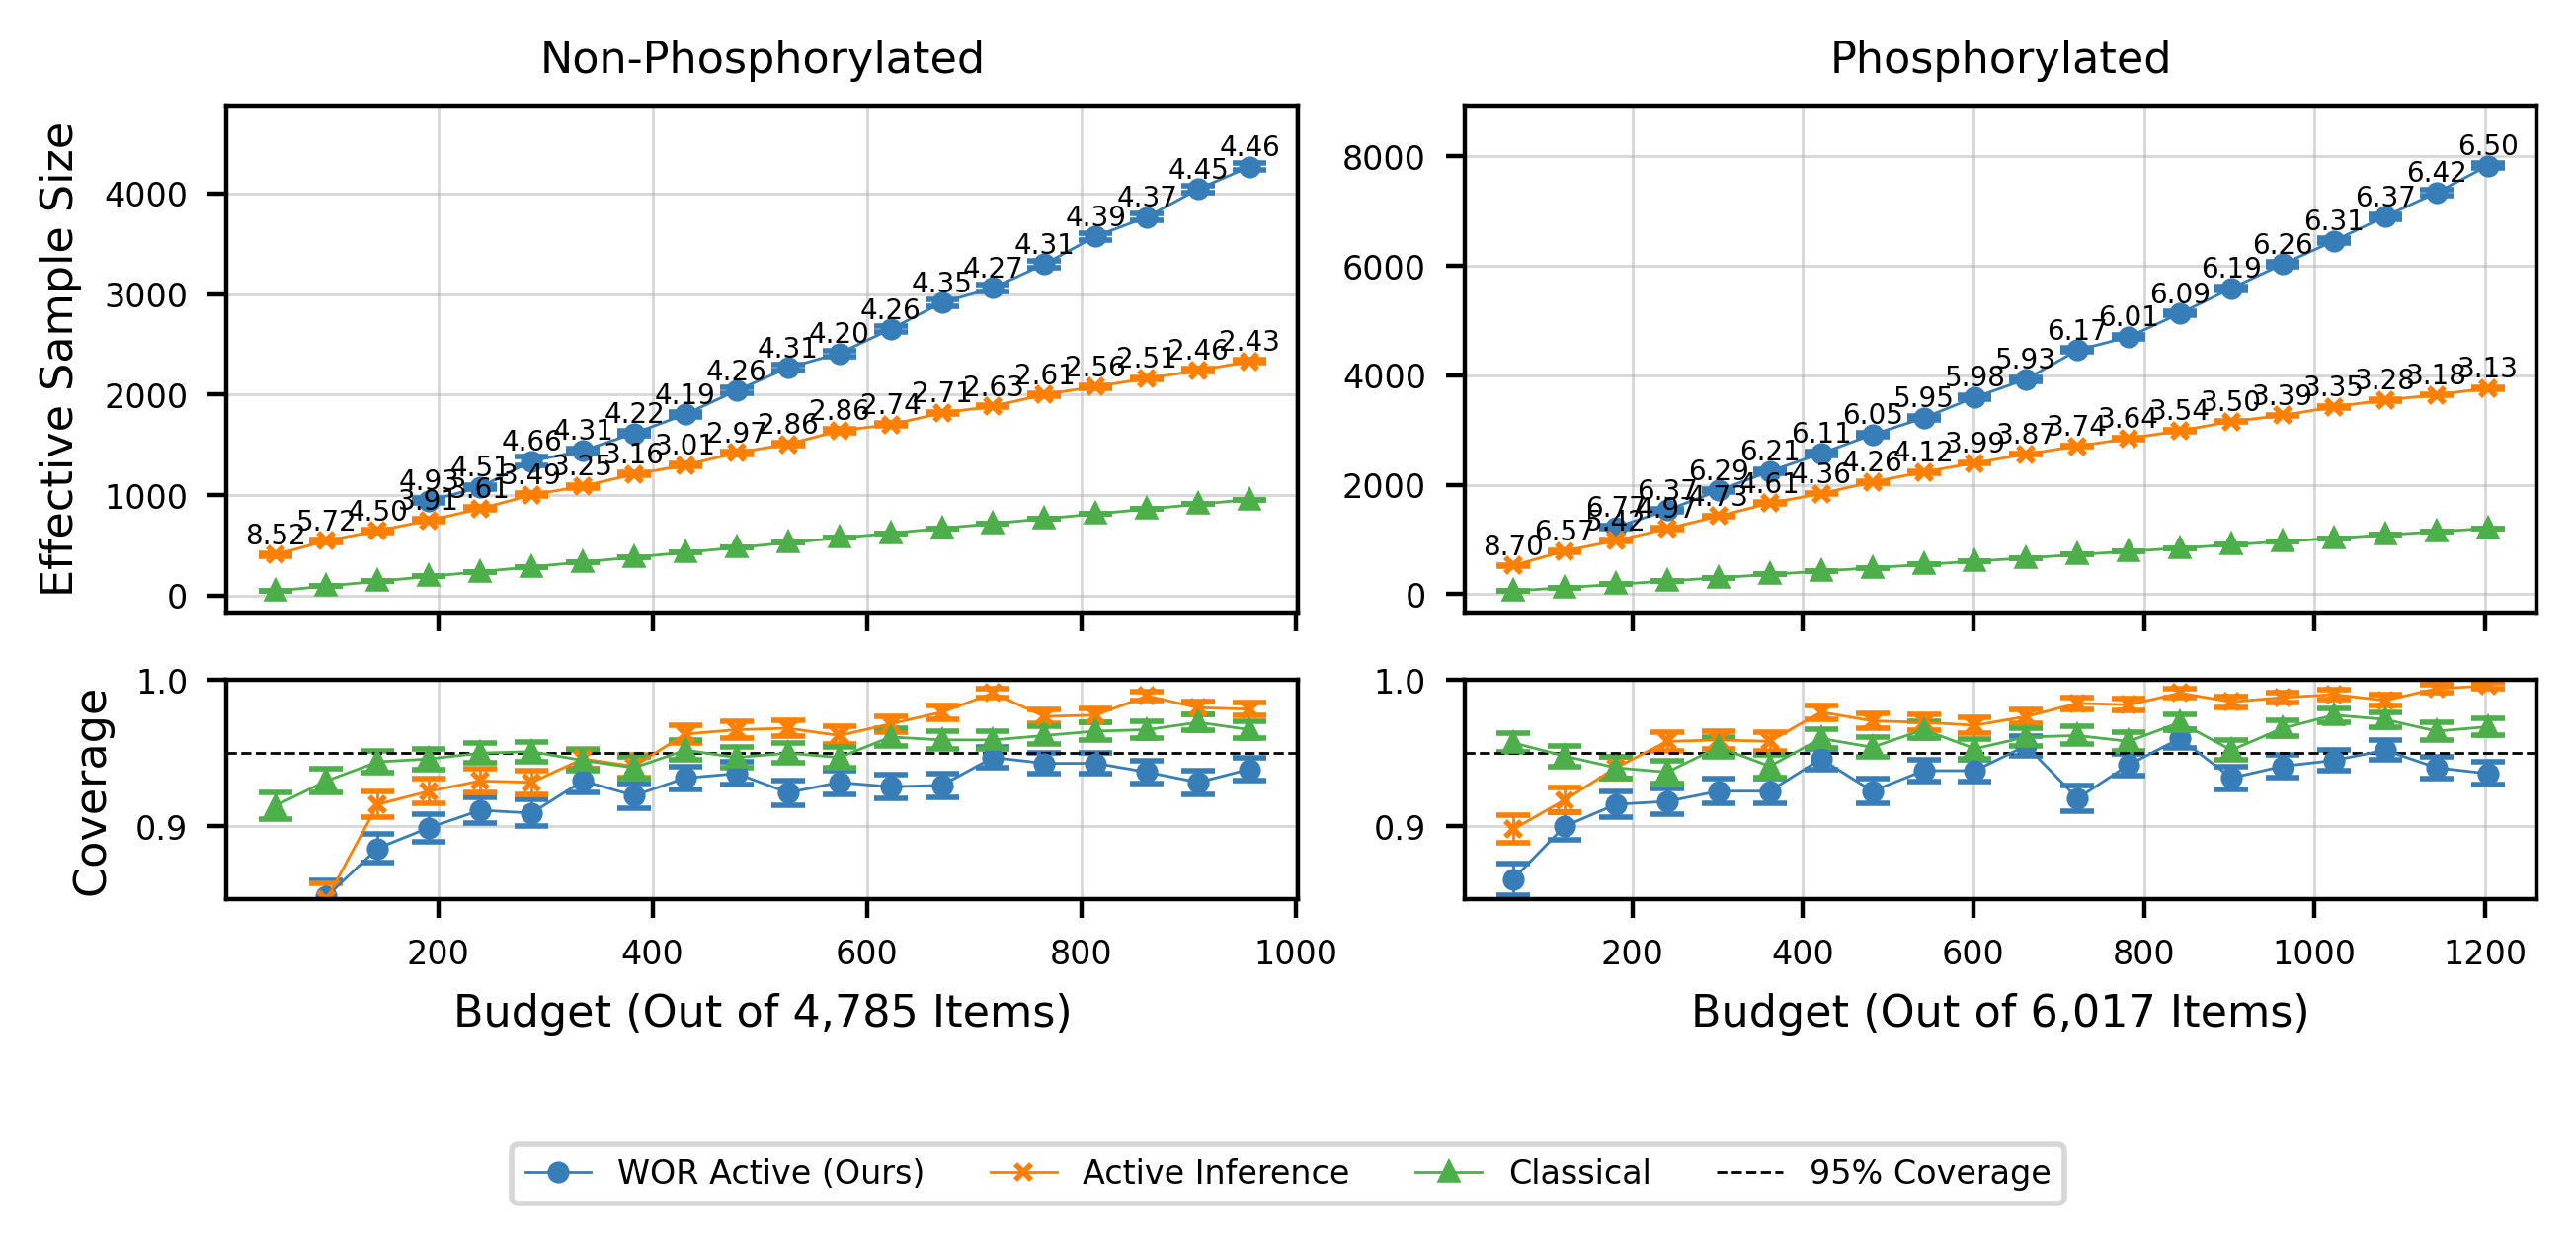

In [7]:
method_config_main = [
    ("wor-active",       "o", colors[0], "WOR Active (Ours)", True),
    ("bernoulli-active", "x", colors[1], "Active Inference",  True),
    ("classical",        "^", colors[2], "Classical",         False),
]

make_figure("ess_multiplier_vs_classical", "ess_multiplier_vs_classical_serr",
            method_config_main,
            f"{RESULTS}/alphafold_main.pdf", legend_ncol=4)

Saved results/alphafold_main_sparse.pdf


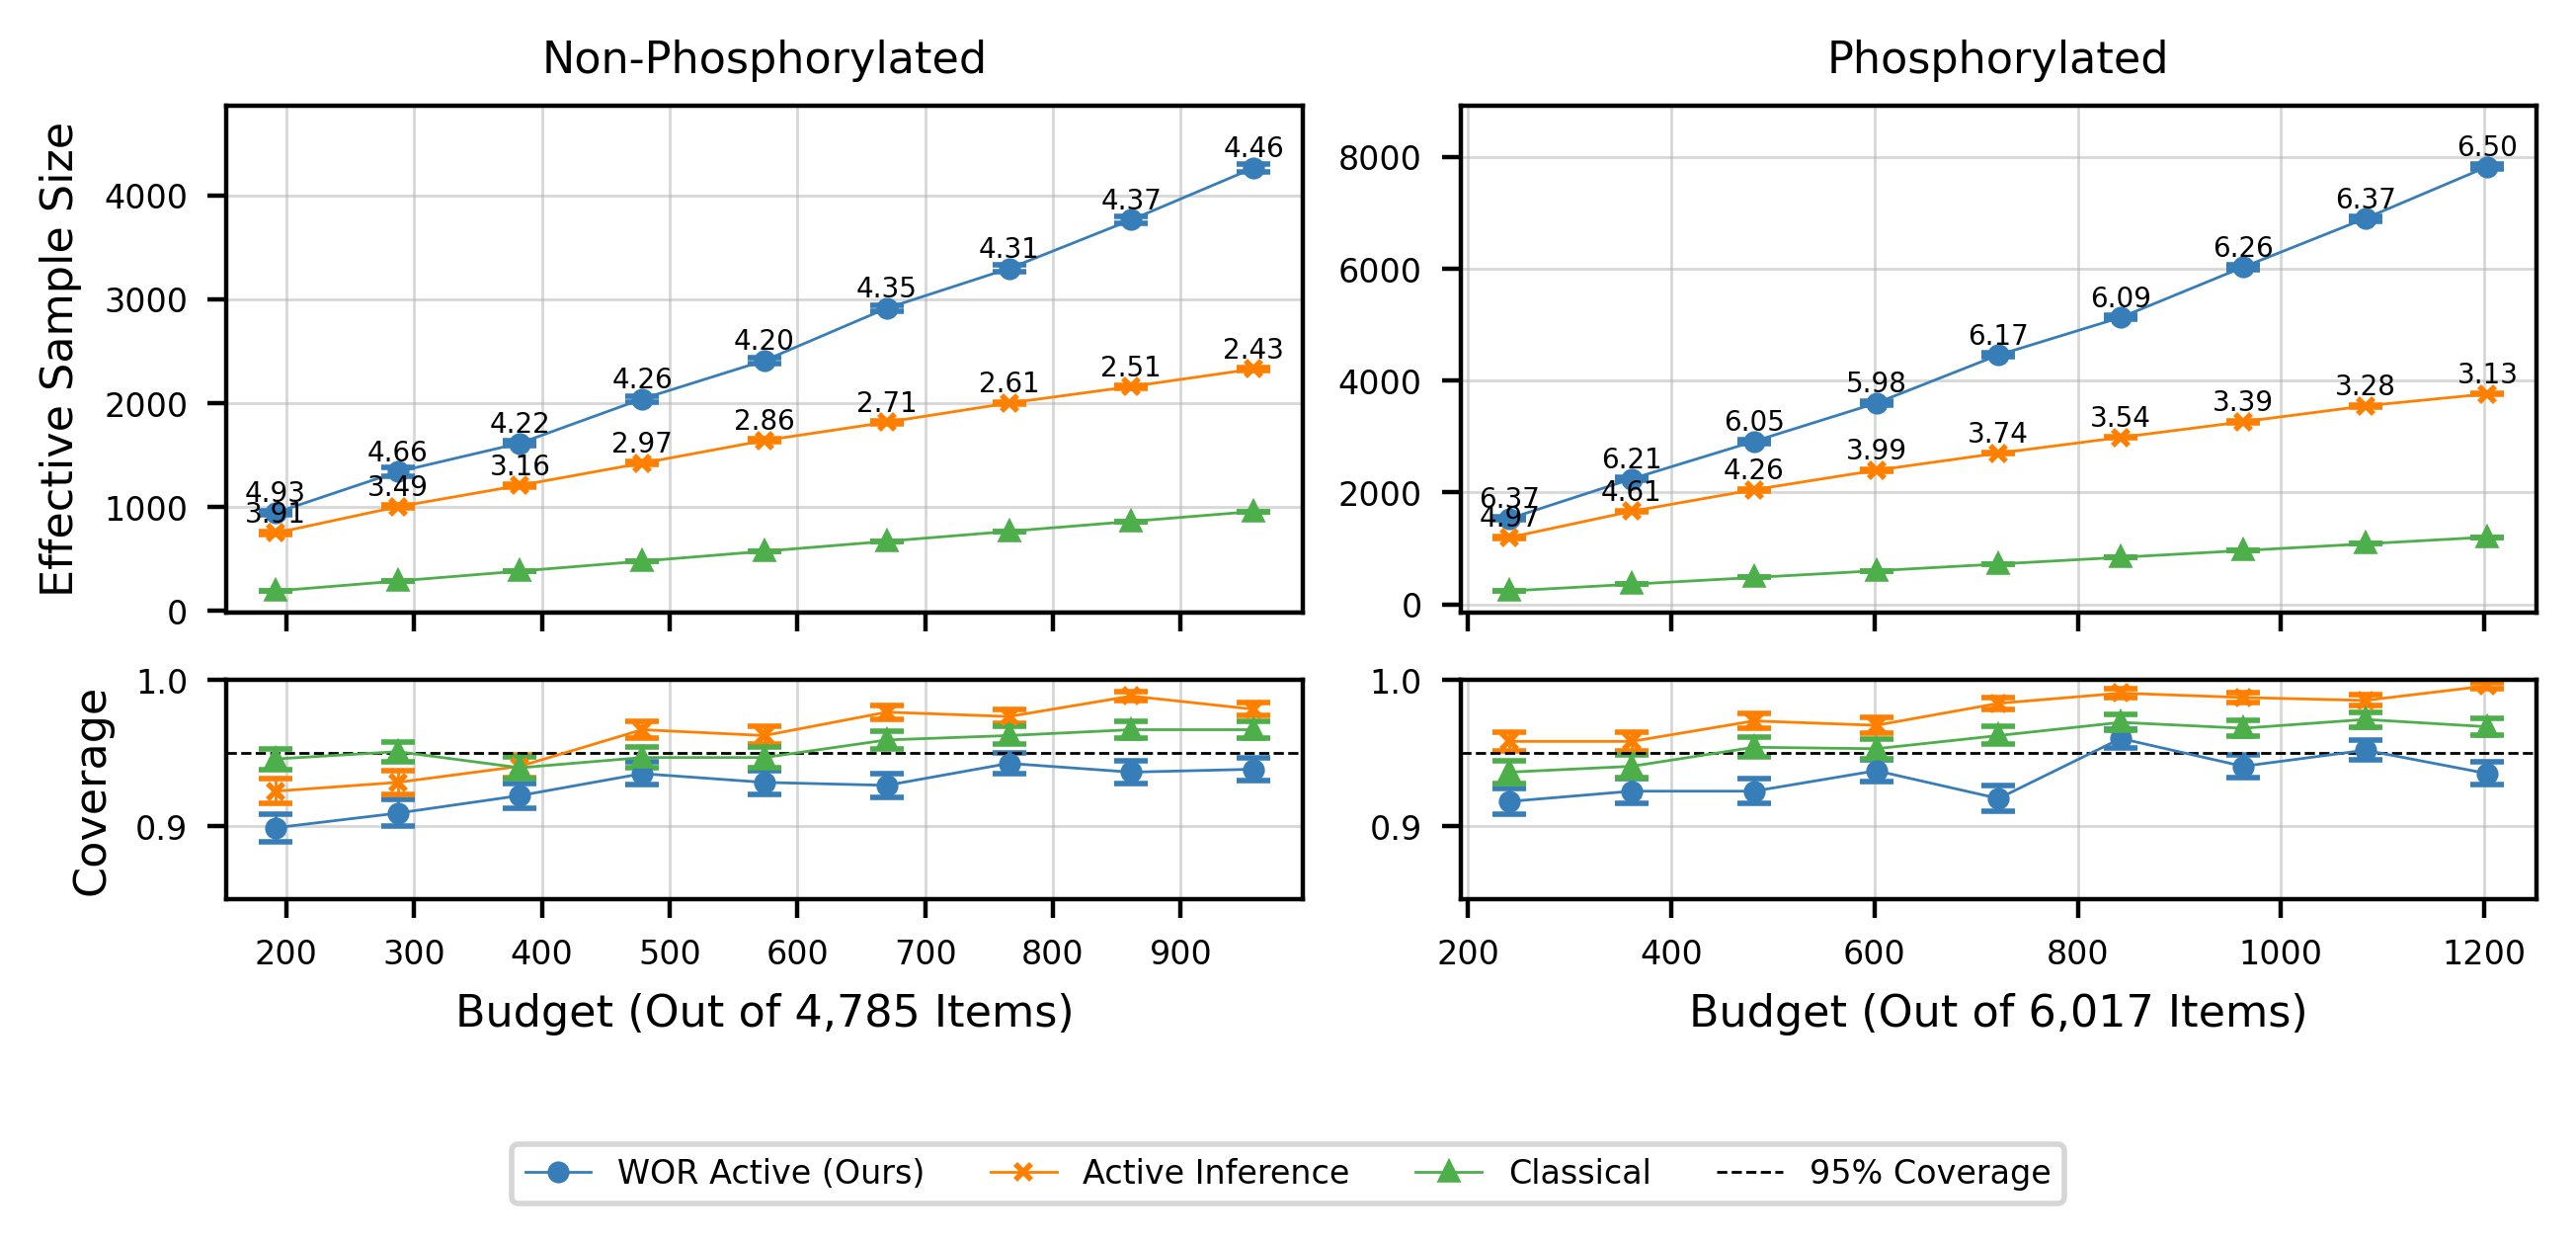

In [8]:
budgets_sparse = np.linspace(0.01, 0.2, 20)[3::2]
make_figure("ess_multiplier_vs_classical", "ess_multiplier_vs_classical_serr",
            method_config_main,
            f"{RESULTS}/alphafold_main_sparse.pdf", legend_ncol=4, budget_subset=budgets_sparse)

Saved results/alphafold_ess+coverage_vs_wor_uniform.pdf


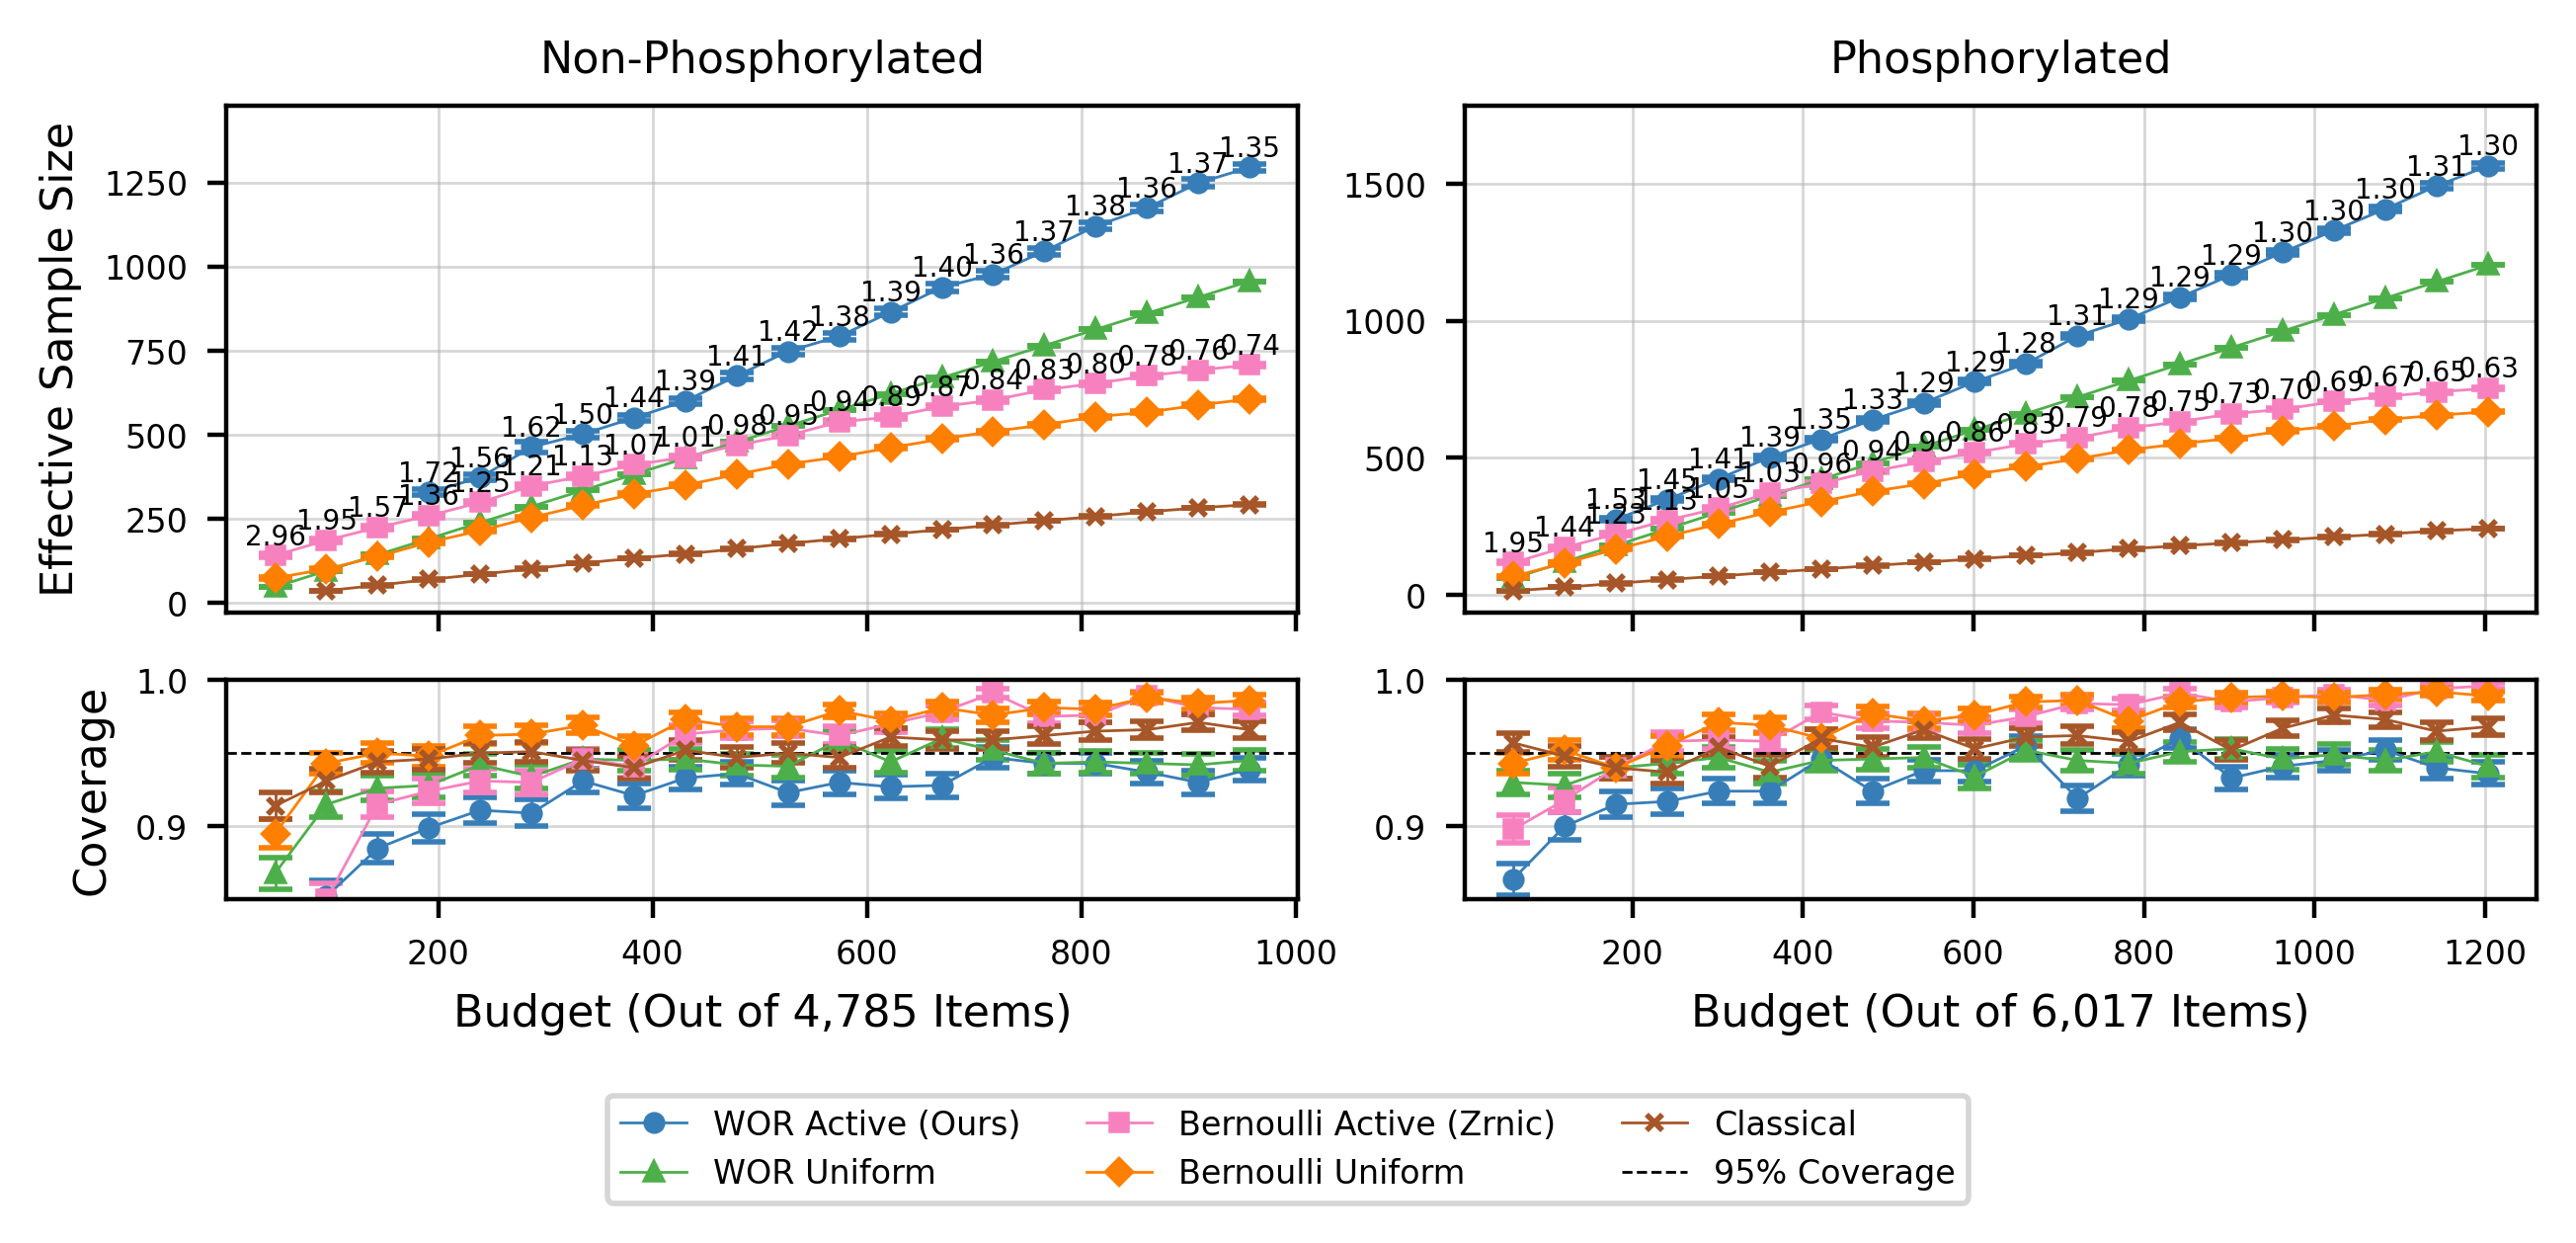

Saved results/alphafold_ess+coverage_vs_classical.pdf


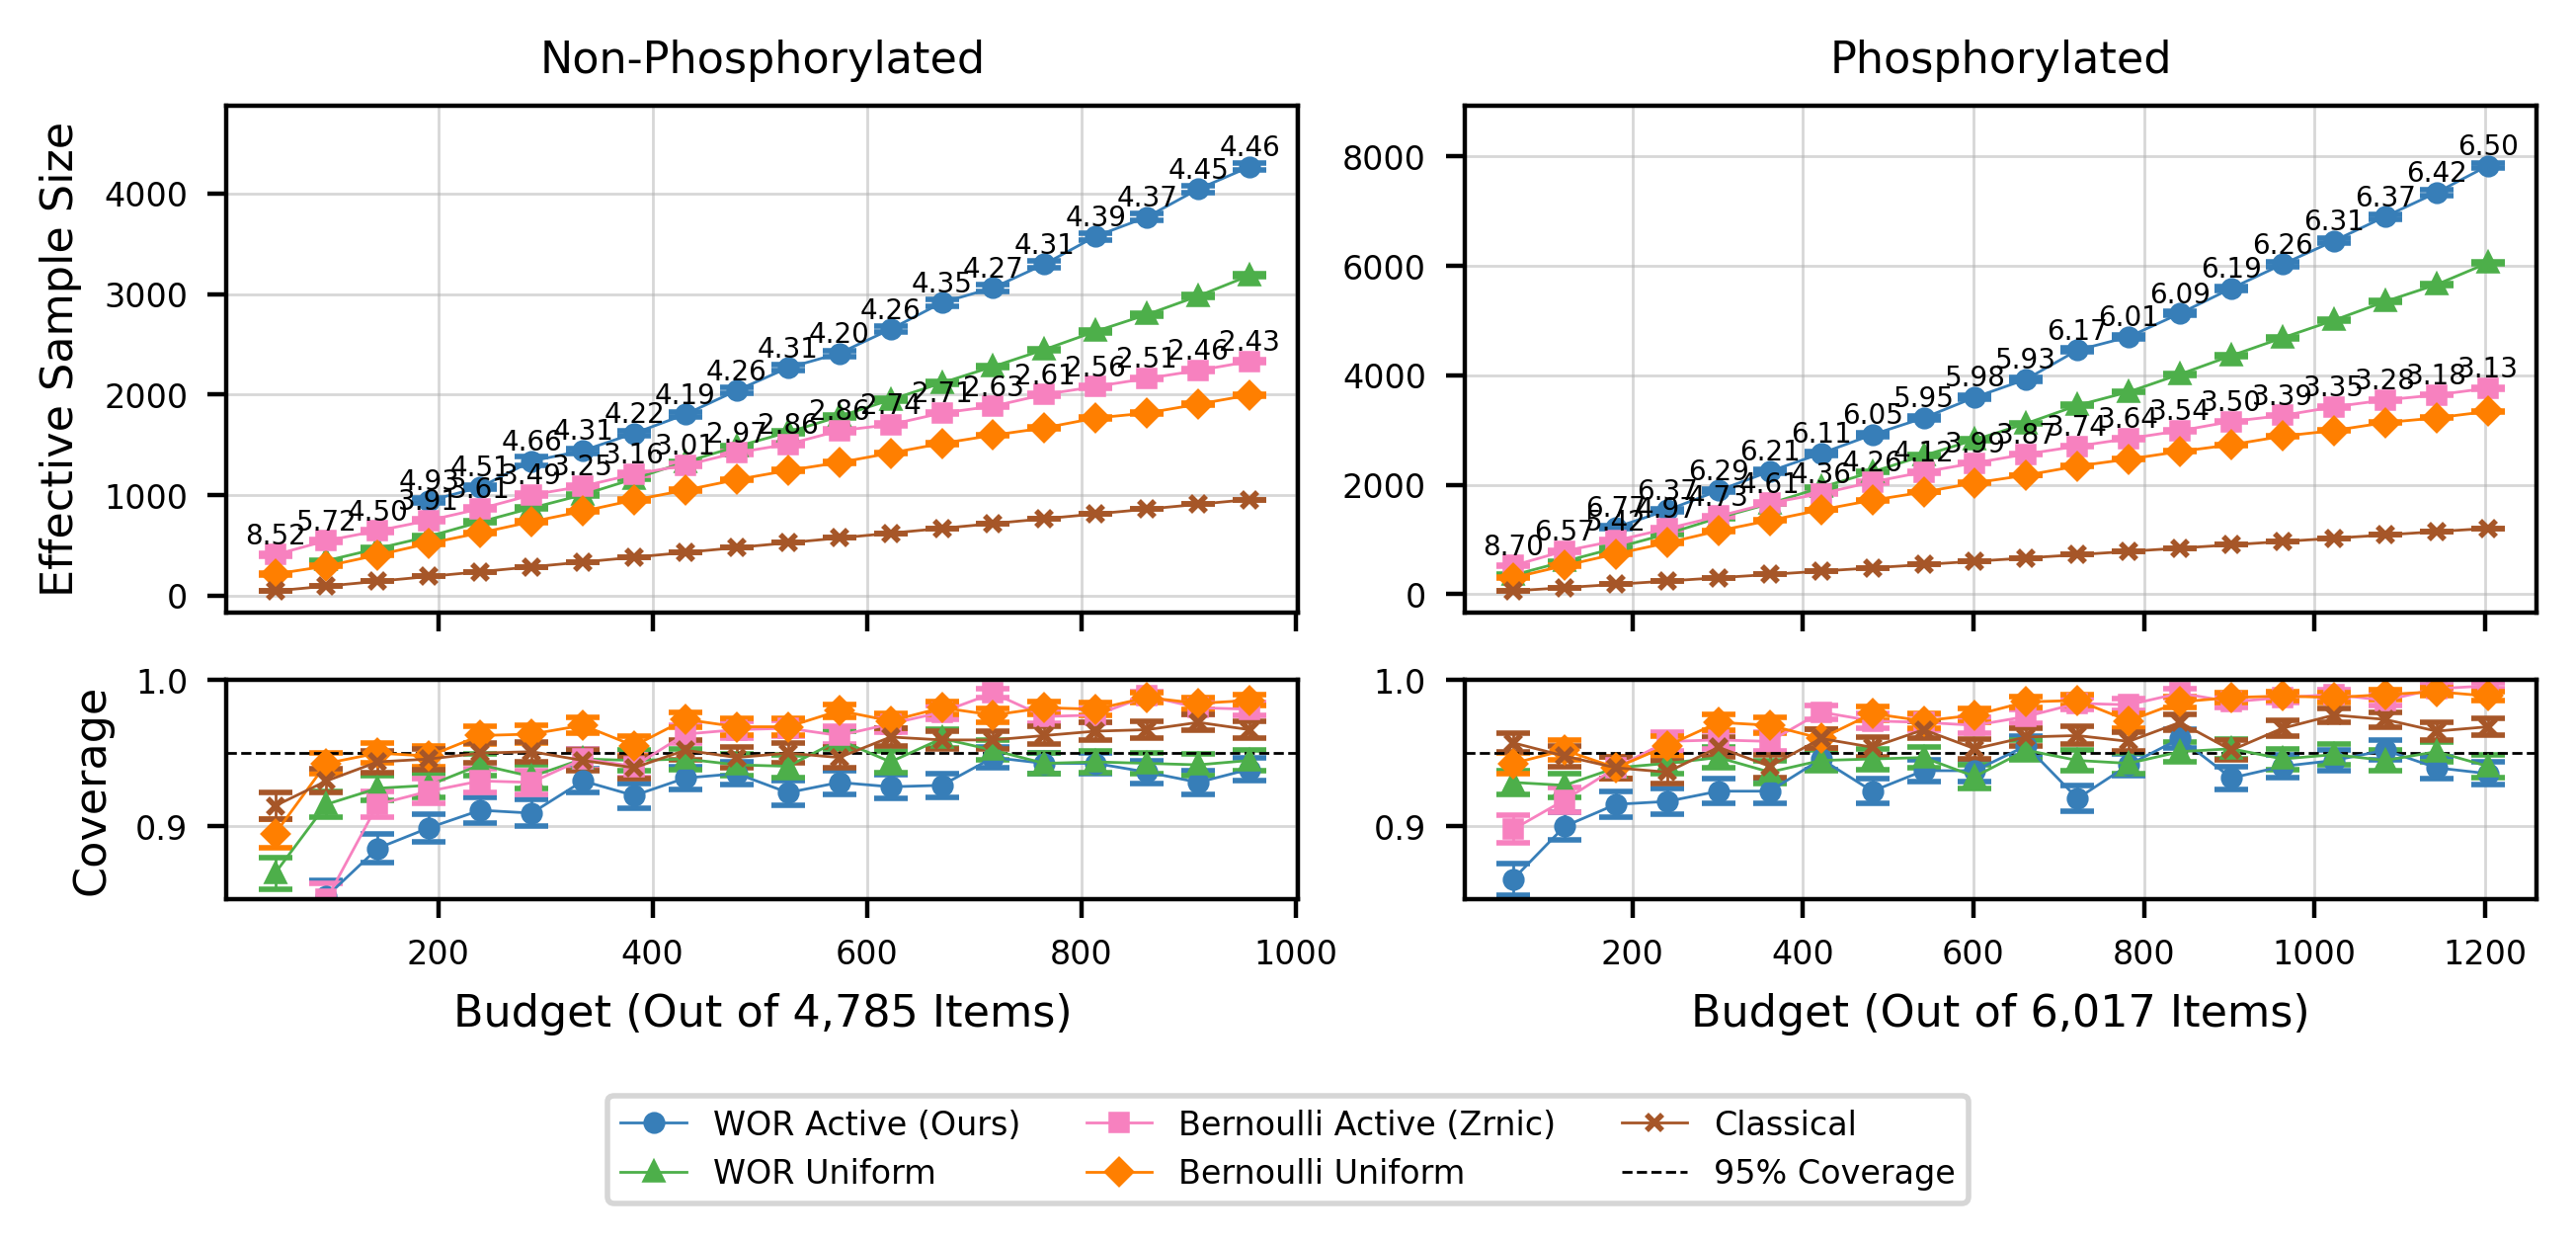

In [9]:
method_config_all = [
    ("wor-active",        "o", colors[0], "WOR Active (Ours)",        True),
    ("wor-uniform",       "^", colors[2], "WOR Uniform",              False),
    ("bernoulli-active",  "s", colors[3], "Bernoulli Active (Zrnic)", True),
    ("bernoulli-uniform", "D", colors[1], "Bernoulli Uniform",        False),
    ("classical",         "x", colors[4], "Classical",                False),
]

make_figure("ess_multiplier", "ess_multiplier_serr",
            method_config_all,
            f"{RESULTS}/alphafold_ess+coverage_vs_wor_uniform.pdf")

make_figure("ess_multiplier_vs_classical", "ess_multiplier_vs_classical_serr",
            method_config_all,
            f"{RESULTS}/alphafold_ess+coverage_vs_classical.pdf")